<a href="https://colab.research.google.com/github/jiafenggang/Algo_F/blob/master/synthmorph_affine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This demo trains an anatomy-aware affine registration network with SynthMorph,
# a strategy for learning image registration with variable synthetic data only.
# Further information is available at https://synthmorph.io.
#
# If you find the demo useful, please cite:
#
#     Anatomy-specific acquisition-agnostic affine registration learned from fictitious images
#     Hoffmann M, Hoopes A, Fischl B*, Dalca AV* (*equal contribution)
#     SPIE Medical Imaging: Image Processing, 12464, p 1246402, 2023
#     https://doi.org/10.1117/12.2653251
#     https://synthmorph.io/#papers (PDF)
#
# We distribute this notebook under the MIT License:
# https://choosealicense.com/licenses/mit

In [ ]:
# Packages from GitHub.
!pip -q install https://github.com/adalca/neurite/archive/17aa080540b61e72ed1f5f37378df41c8278dc3e.zip
!pip -q install https://github.com/freesurfer/surfa/archive/8de6c4584eee9283c50f2d7e215eaf8ff1469770.zip
!pip -q install https://github.com/voxelmorph/voxelmorph/archive/cc84aa7fe255bac6f3bad6f124106e61ea9312cf.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.8/133.8 kB 3.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     - 131.4 kB 7.4 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 MB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import surfa as sf
import neurite as ne
import voxelmorph as vxm
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
# SynthStrip data (https://synthstrip.io).
data = 'synthstrip_data_v1.5_2d'
!gdown -cO {data}.tar 1IvVw2JxD690P8v4mc6FMi4hx6xlx9hV6
!tar xf {data}.tar
!ls

Downloading...
From: https://drive.google.com/uc?id=1IvVw2JxD690P8v4mc6FMi4hx6xlx9hV6
To: /content/synthstrip_data_v1.5_2d.tar
100% 40.4M/40.4M [00:00<00:00, 192MB/s]
sample_data  synthstrip_data_v1.5_2d  synthstrip_data_v1.5_2d.tar


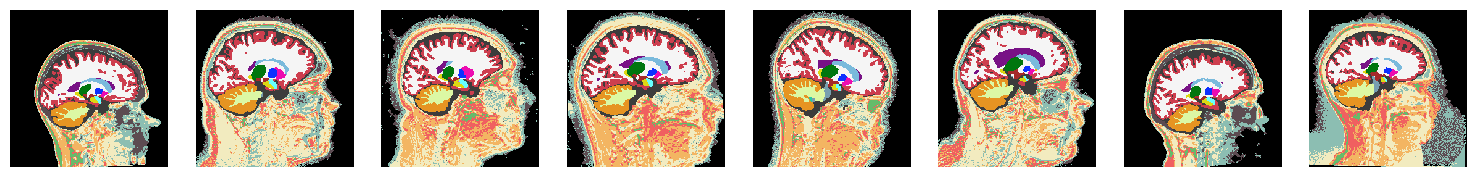

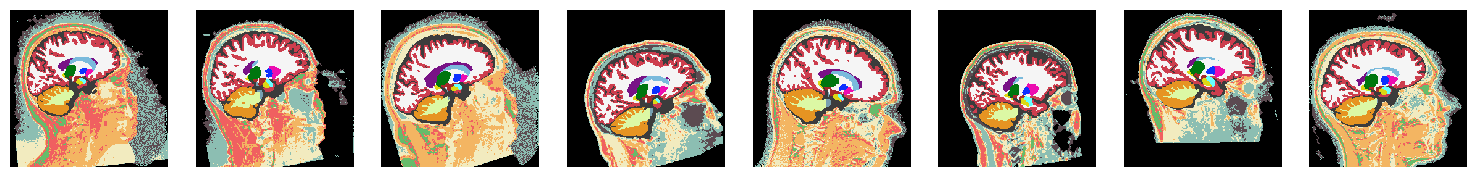

In [ ]:
# Label maps for synthesis.
labels, label_maps = vxm.py.utils.load_labels(f'{data}/*/labels.nii.gz')
shape = label_maps[0].shape


# Color map.
lut = ne.py.utils.load_fs_lut(f'{data}/seg_labels.txt')
cmap = ne.py.utils.fs_lut_to_cmap(lut)


# Visualize.
num_row = 2
per_row = 8
for i in range(0, num_row * per_row, per_row):
  ne.plot.slices(label_maps[i:i + per_row], cmaps=[cmap])

In [ ]:
# Merge labels into larger structures.
labels_out = {}
for k, v in lut.items():
  if 'Cerebellum' in v['name']:
    labels_out[k] = 'Cerebellum'
  elif v['name'].startswith(('Left', 'Right')):
    labels_out[k] = 'Cerebrum'


# Show mapping.
width = max(len(v['name']) for v in lut.values())
for k, v in labels_out.items():
  print(lut[k]['name'].rjust(width), '->', v)

   Left-Cerebral-White-Matter -> Cerebrum
         Left-Cerebral-Cortex -> Cerebrum
       Left-Lateral-Ventricle -> Cerebrum
            Left-Inf-Lat-Vent -> Cerebrum
 Left-Cerebellum-White-Matter -> Cerebellum
       Left-Cerebellum-Cortex -> Cerebellum
                Left-Thalamus -> Cerebrum
                 Left-Caudate -> Cerebrum
                 Left-Putamen -> Cerebrum
                Left-Pallidum -> Cerebrum
             Left-Hippocampus -> Cerebrum
                Left-Amygdala -> Cerebrum
          Left-Accumbens-area -> Cerebrum
               Left-VentralDC -> Cerebrum
  Right-Cerebral-White-Matter -> Cerebrum
        Right-Cerebral-Cortex -> Cerebrum
      Right-Lateral-Ventricle -> Cerebrum
           Right-Inf-Lat-Vent -> Cerebrum
Right-Cerebellum-White-Matter -> Cerebellum
      Right-Cerebellum-Cortex -> Cerebellum
               Right-Thalamus -> Cerebrum
                Right-Caudate -> Cerebrum
                Right-Putamen -> Cerebrum
               Right-Palli

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


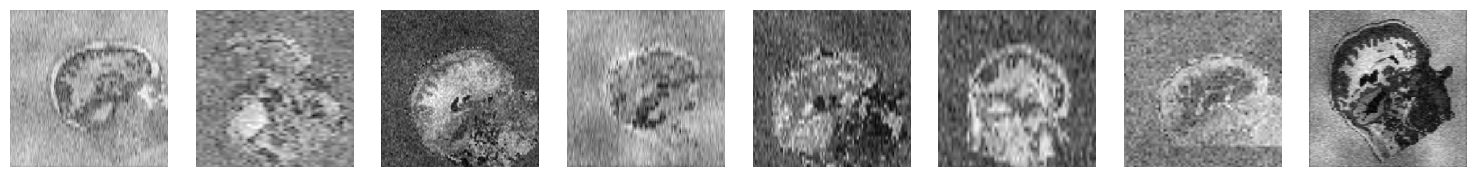

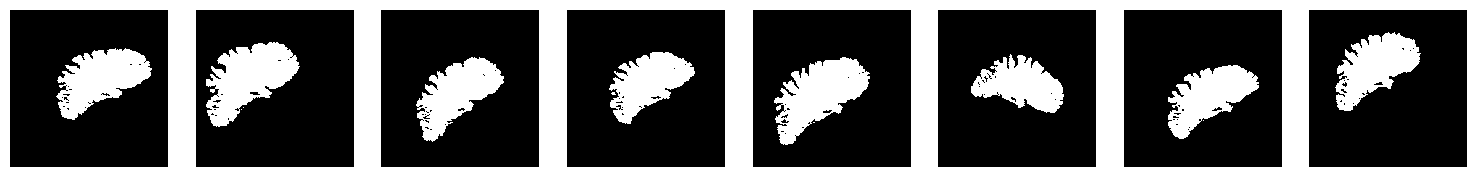

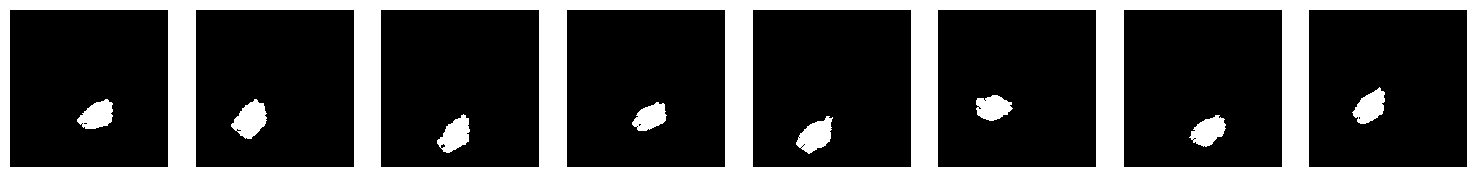

In [ ]:
# Training-image generation.
prop = dict(
  in_shape=shape,
  labels_in=labels,
  labels_out=labels_out,
  aff_shift=30,
  aff_rotate=45,
  aff_scale=0.1,
  aff_shear=0.1,
  blur_max=1,
  slice_prob=1,
  crop_prob=1,
)
model_gen_1 = ne.models.labels_to_image(**prop, id=1)
model_gen_2 = ne.models.labels_to_image(**prop, id=2)


# Test repeatedly on the same input.
num_gen = 8
input = np.expand_dims(label_maps[0], axis=(0, -1))
images, one_hot = zip(*(model_gen_1.predict(input) for _ in range(num_gen)))


# Example images and structures to align.
ne.plot.slices(images)
for i in range(one_hot[0].shape[-1]):
  ne.plot.slices([f[..., i] for f in one_hot]);

In [ ]:
# Registration model.
model_aff = vxm.networks.VxmAffineFeatureDetector(shape)


# Moved labels.
ima_1, map_1 = model_gen_1.outputs
ima_2, map_2 = model_gen_2.outputs

trans = model_aff((ima_1, ima_2))
moved = vxm.layers.SpatialTransformer(fill_value=0)((map_1, trans))


# Contrast invariance: MSE loss on probability maps.
class AddLoss(tf.keras.layers.Layer):
  def call(self, x):
    self.add_loss(vxm.losses.MSE().loss(*x))
    return x

# Combined model: synthesis and registration.
input = (*model_gen_1.inputs, *model_gen_2.inputs)
model = tf.keras.Model(input, AddLoss()((moved, map_2)))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - loss: 0.1073
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0985
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1170


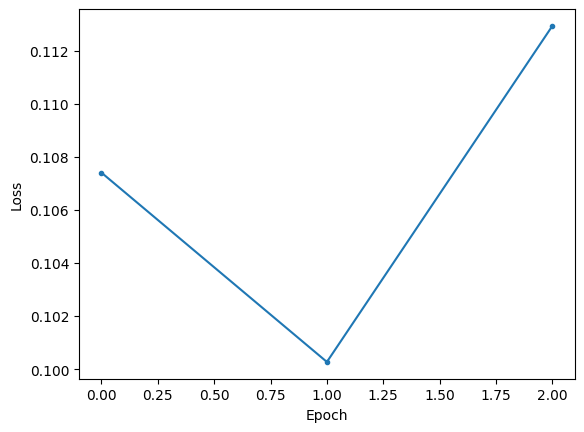

In [ ]:
# Training. Re-running the cell will continue training.
hist = model.fit(
  vxm.generators.synthmorph(label_maps),
  epochs=3,
  steps_per_epoch=100,
)


# Visualize loss.
plt.plot(hist.epoch, hist.history['loss'], '.-')
plt.xlabel('Epoch')
plt.ylabel('Loss');

In [ ]:
# Skip training, download model weights.
!gdown -cO weights.h5 1DWiVxCvQmYDSBS1RcVbUeTxX0XArQsGv
model.load_weights('weights.h5')

Downloading...
From: https://drive.google.com/uc?id=1DWiVxCvQmYDSBS1RcVbUeTxX0XArQsGv
To: /content/weights.h5
100% 17.3M/17.3M [00:00<00:00, 137MB/s]


In [ ]:
# Potential test subjects. Training used label maps from T1w ASL/FSM/IXI scans.
%ls {data}

asl_epi_101/  fsm_qt1_01ob/  infant_t1_23/  ixi_pd_277/  qin_flair_01/
asl_epi_105/  fsm_qt1_02cd/  infant_t1_24/  ixi_pd_278/  qin_flair_02/
asl_epi_106/  fsm_qt1_08un/  infant_t1_25/  ixi_pd_397/  qin_flair_03/
asl_epi_109/  fsm_qt1_10cv/  infant_t1_26/  ixi_pd_398/  qin_flair_04/
asl_epi_110/  fsm_qt1_11ni/  ixi_dwi_002/   ixi_pd_399/  qin_flair_05/
asl_epi_111/  fsm_qt1_14pu/  ixi_dwi_012/   ixi_pd_400/  qin_flair_06/
asl_epi_112/  fsm_qt1_21em/  ixi_dwi_013/   ixi_pd_401/  qin_flair_07/
asl_epi_113/  fsm_qt1_22db/  ixi_dwi_015/   ixi_pd_518/  qin_flair_08/
asl_epi_114/  fsm_qt1_23qf/  ixi_dwi_136/   ixi_pd_519/  qin_flair_09/
asl_epi_115/  fsm_qt1_24dz/  ixi_dwi_137/   ixi_pd_521/  qin_flair_10/
asl_epi_116/  fsm_qt1_27uz/  ixi_dwi_139/   ixi_pd_522/  qin_flair_13/
asl_epi_117/  fsm_qt1_30gy/  ixi_dwi_266/   ixi_pd_523/  qin_flair_14/
asl_epi_118/  fsm_qt1_39ap/  ixi_dwi_267/   ixi_pd_524/  qin_flair_15/
asl_epi_119/  fsm_qt1_40mn/  ixi_dwi_268/   ixi_pd_525/  qin_flair_43/
asl_ep

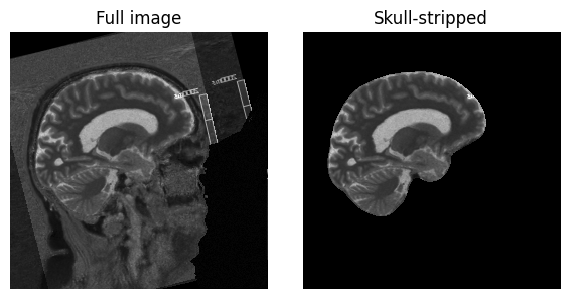

In [ ]:
# Input conformation
def conform(f):
  # Conform to shape, isotropic 1-mm resolution. The function interpolates in
  # 3D, so we stack 3 copies of the 2D image to avoid all-zero outputs when
  # the through-plane coordinate is not exactly zero.
  out = sf.load_volume(f)
  pad = np.concatenate([out.data] * 3, axis=-1)
  out = out.new(pad)
  out = out.conform(
    voxsize=(1, 1, out.geom.voxsize[2]),
    shape=(*shape, out.shape[-1]),
    dtype=np.float32,
    method='nearest',
  )[..., 1]

  # Normalize, add batch and feature dimension.
  out = ne.utils.minmax_norm(out)
  return out[None, ..., None]


# Skull-strip for difference images.
def load_and_strip(subj):
  imag = conform(f=f'{data}/{subj}/image.nii.gz')
  mask = conform(f=f'{data}/{subj}/mask.nii.gz')
  return imag, tf.multiply(imag, mask)


# Visualize output.
slices = load_and_strip(subj='fsm_qt1_79bf')
ne.plot.slices(slices, titles=('Full image', 'Skull-stripped'), width=len(slices) * 3);

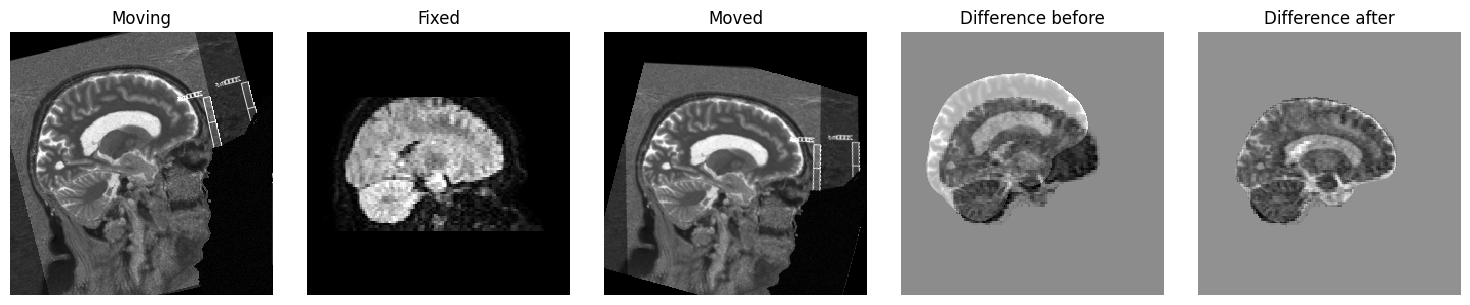

In [ ]:
# Registration.
def register(moving, fixed):
  # Load images.
  im_1, br_1 = load_and_strip(moving)
  im_2, br_2 = load_and_strip(fixed)

  # Register.
  trans = model_aff.predict((im_1, im_2), verbose=0)
  out_im = vxm.layers.SpatialTransformer(fill_value=0)((im_1, trans))
  out_br = vxm.layers.SpatialTransformer(fill_value=0)((br_1, trans))

  # Re-normalize for visualization.
  slices = (im_1, im_2, br_1, br_2, out_im, out_br)
  slices = (np.clip(f, *np.percentile(f, q=(0.1, 99.9))) for f in slices)
  im_1, im_2, br_1, br_2, out_im, out_br = slices

  # Plot.
  slices = (im_1, im_2, out_im, br_1 - br_2, out_br - br_2)
  titles = ('Moving', 'Fixed', 'Moved', 'Difference before', 'Difference after')
  ne.plot.slices(slices, titles=titles, width=len(slices) * 3)


# Defaced quantitative-T1 map to low-resolution DWI.
register(moving='fsm_qt1_79bf', fixed='ixi_dwi_401')

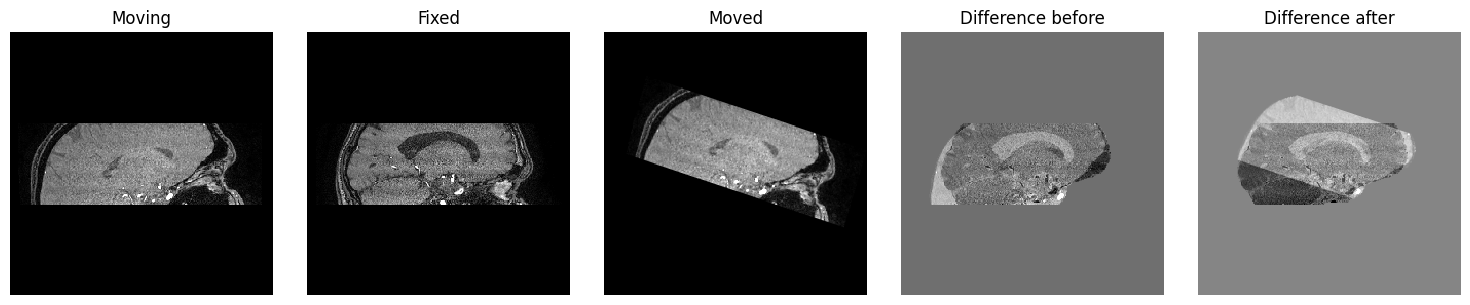

In [ ]:
# Partial-FOV MRA to different-partial-FOV MRA.
register(moving='ixi_mra_012', fixed='ixi_mra_016')

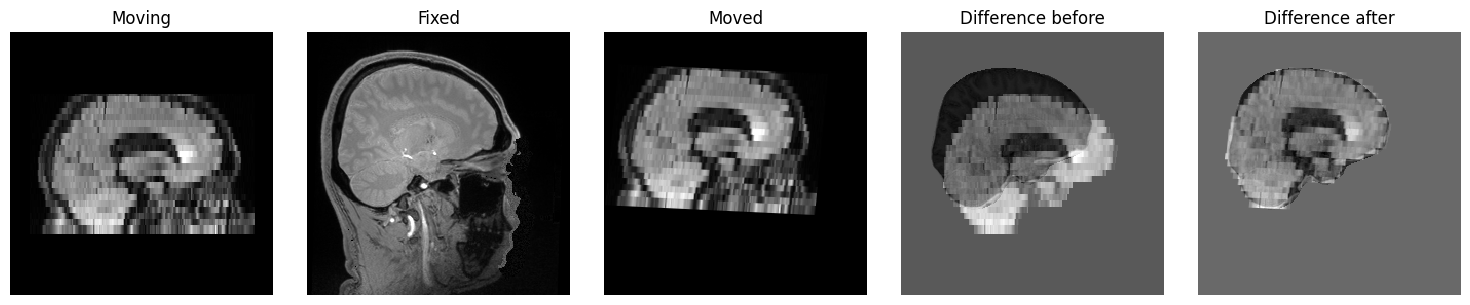

In [ ]:
# Clinical thick-slice T2-FLAIR 2D-FSE to defaced PDw 3D-FLASH.
register(moving='qin_flair_07', fixed='fsm_pd_50ww')

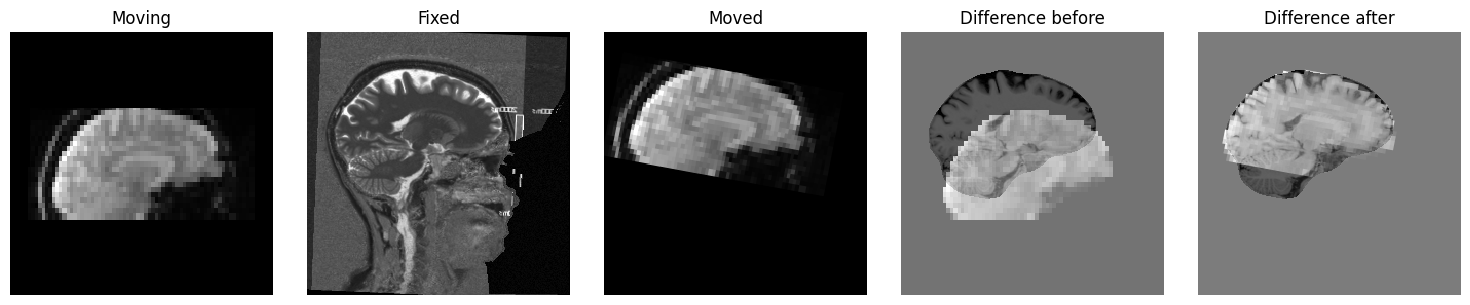

In [ ]:
# Low-resolution partial-FOV 2D-EPI to defaced quantitative-T1 map.
register(moving='asl_epi_134', fixed='fsm_qt1_87qb')

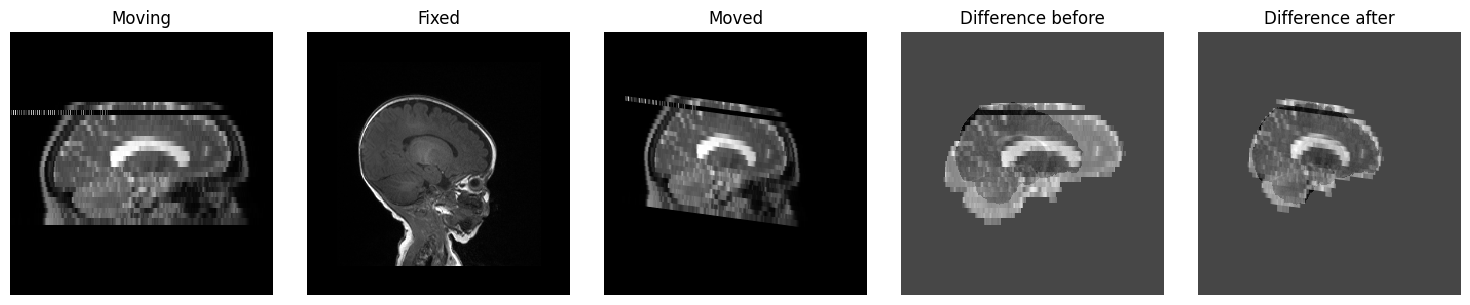

In [ ]:
# Clinical T2w thick-slice 2D-FSE with glitch to T1w infant MPRAGE.
register(moving='qin_t2_05', fixed='infant_t1_17')

In [ ]:
# Package versions.
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.7.2
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.8.18.0.40.14
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
Authlib==1.6.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.21.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.15.0
bigquery-magics==0.10.2
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.7.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.8.3
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
clarabel==0.11.1
click==8.2.1
cl